<a href="https://colab.research.google.com/github/surajkrpirari2007/surajkasdj/blob/main/crop_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

data=pd.read_csv("crop_yield_dataset.csv")
data.columns

Index(['Crop', 'Region', 'Soil_Type', 'Soil_pH', 'Rainfall_mm',
       'Temperature_C', 'Humidity_pct', 'Fertilizer_Used_kg', 'Irrigation',
       'Pesticides_Used_kg', 'Planting_Density', 'Previous_Crop',
       'Yield_ton_per_ha'],
      dtype='object')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Crop                10000 non-null  object 
 1   Region              10000 non-null  object 
 2   Soil_Type           10000 non-null  object 
 3   Soil_pH             10000 non-null  float64
 4   Rainfall_mm         10000 non-null  float64
 5   Temperature_C       10000 non-null  float64
 6   Humidity_pct        10000 non-null  float64
 7   Fertilizer_Used_kg  10000 non-null  float64
 8   Irrigation          7462 non-null   object 
 9   Pesticides_Used_kg  10000 non-null  float64
 10  Planting_Density    10000 non-null  float64
 11  Previous_Crop       7969 non-null   object 
 12  Yield_ton_per_ha    10000 non-null  float64
dtypes: float64(8), object(5)
memory usage: 1015.8+ KB


In [ ]:
data['Crop'].value_counts()

,count
Crop,
Rice,2536
Barley,2501
Wheat,2486
Maize,2477


In [ ]:
data['Previous_Crop'].value_counts()

,count
Previous_Crop,
Rice,2072
Maize,1972
Barley,1965
Wheat,1960


In [ ]:
data['Irrigation'].value_counts()

,count
Irrigation,
Flood,2530
Drip,2472
Sprinkler,2460


In [ ]:
data.describe

<bound method NDFrame.describe of         Crop    Region Soil_Type  Soil_pH  Rainfall_mm  Temperature_C  \
0      Maize  Region_C     Sandy     7.01       1485.4           19.7   
1     Barley  Region_D      Loam     5.79        399.4           29.1   
2       Rice  Region_C      Clay     7.24        980.9           30.5   
3      Maize  Region_D      Loam     6.79       1054.3           26.4   
4      Maize  Region_D     Sandy     5.96        744.6           20.4   
...      ...       ...       ...      ...          ...            ...   
9995  Barley  Region_A      Clay     5.84        890.4           28.5   
9996   Maize  Region_A     Sandy     6.91        614.2           30.0   
9997   Wheat  Region_A      Clay     6.98        842.0           22.6   
9998   Wheat  Region_D     Sandy     7.27        924.2           26.8   
9999    Rice  Region_C     Sandy     5.95        247.0           31.1   

      Humidity_pct  Fertilizer_Used_kg Irrigation  Pesticides_Used_kg  \
0             40.3               105.1       Drip                10.2   
1             55.4               221.8  Sprinkler                35.5   
2             74.4                61.2  Sprinkler                40.0   
3             62.0               257.8       Drip                42.7   
4             70.9               195.8       Drip                25.5   
...            ...                 ...        ...                 ...   
9995          68.6                82.5      Flood                 4.0   
9996          84.2                85.2        NaN                21.7   
9997          75.1               249.2  Sprinkler                 8.8   
9998          50.8               146.1  Sprinkler                 3.3   
9999          66.2               223.4      Flood                18.7   

      Planting_Density Previous_Crop  Yield_ton_per_ha  
0                 23.2          Rice            101.48  
1                  7.4        Barley            127.39  
2                  5.1         Wheat             68.99  
3                 23.7           NaN            169.06  
4                 15.6         Maize            118.71  
...                ...           ...               ...  
9995              24.1         Wheat             79.83  
9996               8.3         Maize             68.24  
9997              18.1          Rice            159.29  
9998              18.1         Maize             99.08  
9999              12.1          Rice            121.30  

[10000 rows x 13 columns]>

In [ ]:
data['Previous_Crop']=data['Previous_Crop'].fillna(data['Previous_Crop'].mode()[0])
data['Irrigation']=data['Irrigation'].fillna(data['Irrigation'].mode()[0])

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Crop                10000 non-null  object 
 1   Region              10000 non-null  object 
 2   Soil_Type           10000 non-null  object 
 3   Soil_pH             10000 non-null  float64
 4   Rainfall_mm         10000 non-null  float64
 5   Temperature_C       10000 non-null  float64
 6   Humidity_pct        10000 non-null  float64
 7   Fertilizer_Used_kg  10000 non-null  float64
 8   Irrigation          10000 non-null  object 
 9   Pesticides_Used_kg  10000 non-null  float64
 10  Planting_Density    10000 non-null  float64
 11  Previous_Crop       10000 non-null  object 
 12  Yield_ton_per_ha    10000 non-null  float64
dtypes: float64(8), object(5)
memory usage: 1015.8+ KB


In [ ]:
data1=data.copy()
data1.drop(columns='Region',inplace=True)
data1

,Crop,Soil_Type,Soil_pH,Rainfall_mm,Temperature_C,Humidity_pct,Fertilizer_Used_kg,Irrigation,Pesticides_Used_kg,Planting_Density,Previous_Crop,Yield_ton_per_ha
0,Maize,Sandy,7.01,1485.4,19.7,40.3,105.1,Drip,10.2,23.2,Rice,101.48
1,Barley,Loam,5.79,399.4,29.1,55.4,221.8,Sprinkler,35.5,7.4,Barley,127.39
2,Rice,Clay,7.24,980.9,30.5,74.4,61.2,Sprinkler,40.0,5.1,Wheat,68.99
3,Maize,Loam,6.79,1054.3,26.4,62.0,257.8,Drip,42.7,23.7,Rice,169.06
4,Maize,Sandy,5.96,744.6,20.4,70.9,195.8,Drip,25.5,15.6,Maize,118.71
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Barley,Clay,5.84,890.4,28.5,68.6,82.5,Flood,4.0,24.1,Wheat,79.83
9996,Maize,Sandy,6.91,614.2,30.0,84.2,85.2,Flood,21.7,8.3,Maize,68.24
9997,Wheat,Clay,6.98,842.0,22.6,75.1,249.2,Sprinkler,8.8,18.1,Rice,159.29
9998,Wheat,Sandy,7.27,924.2,26.8,50.8,146.1,Sprinkler,3.3,18.1,Maize,99.08


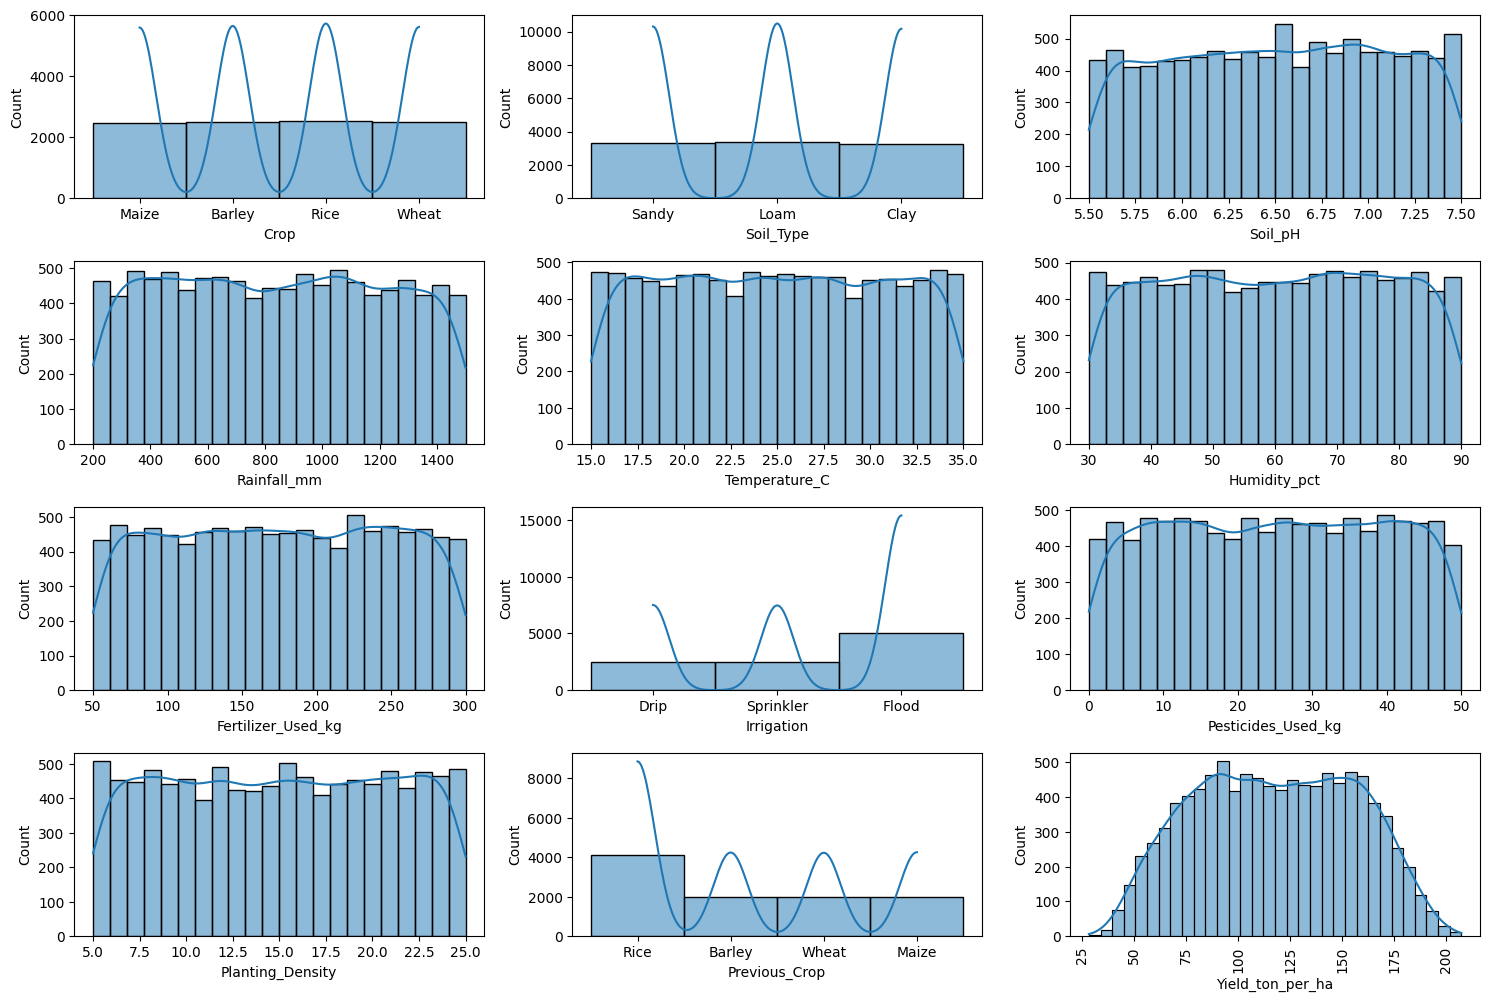

In [ ]:
count=1
plt.figure(figsize=(15,10))
for i in data1.columns:
  plt.subplot(4,3,count)
  sns.histplot(data[i],kde=True)
  count+=1
  plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

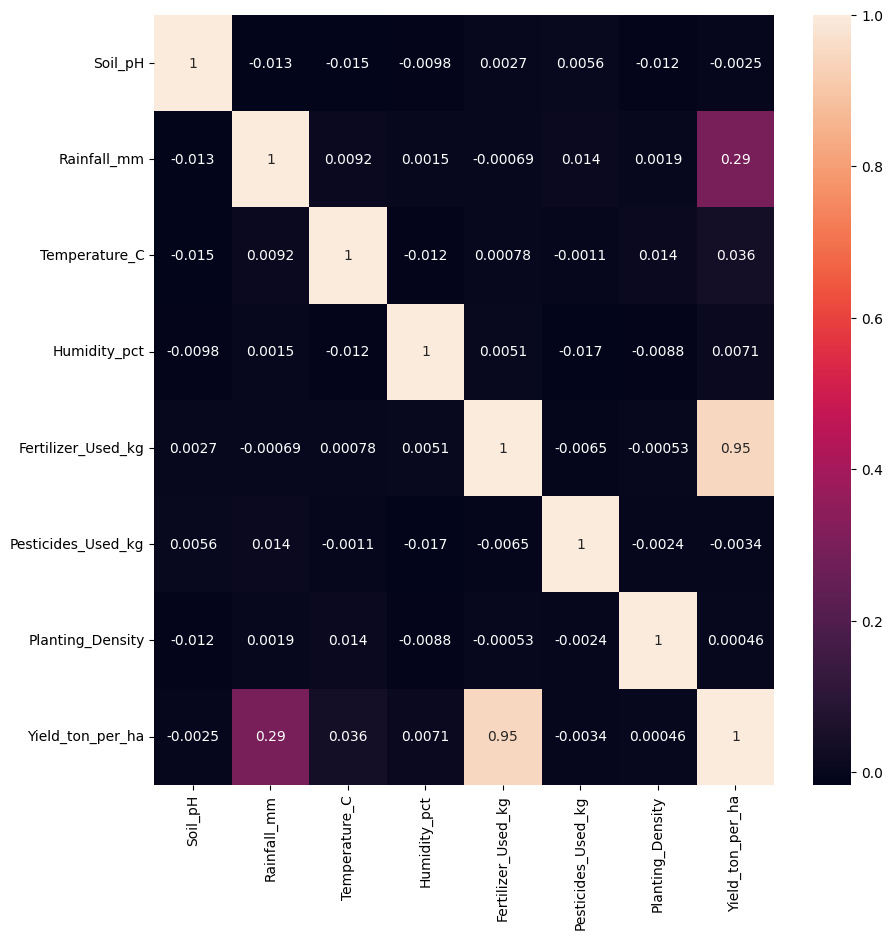

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap(data1.corr(numeric_only=True),annot=True)
plt.show()

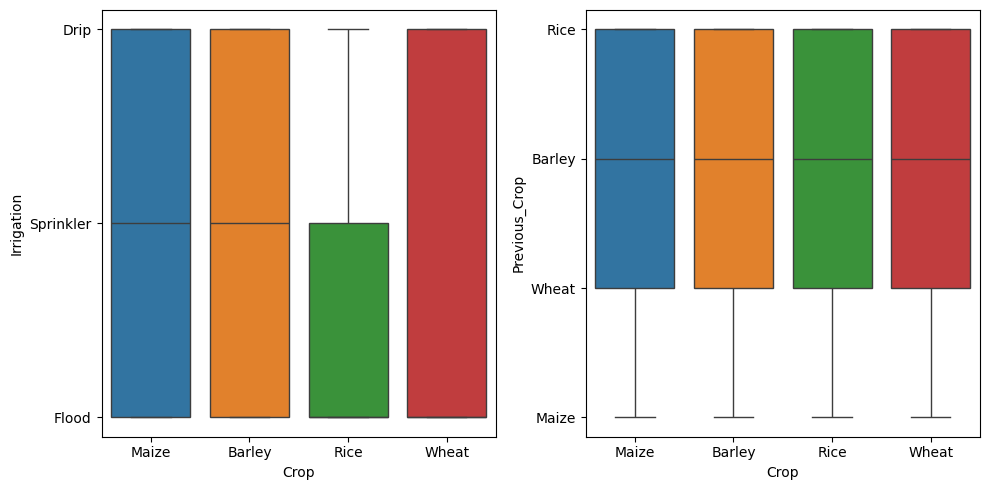

In [ ]:
list_nnc=['Irrigation','Previous_Crop']
plt.figure(figsize=(10,5))
count1=1
for i in list_nnc:
  plt.subplot(1,2,count1)
  sns.boxplot(x=data['Crop'],y=data[i],hue=data['Crop'])
  count1+=1
  plt.tight_layout()
plt.show()


In [ ]:
num_col=data1.select_dtypes(include="number").columns
num_col

Index(['Soil_pH', 'Rainfall_mm', 'Temperature_C', 'Humidity_pct',
       'Fertilizer_Used_kg', 'Pesticides_Used_kg', 'Planting_Density',
       'Yield_ton_per_ha'],
      dtype='object')

<Axes: xlabel='Soil_pH', ylabel='Yield_ton_per_ha'>

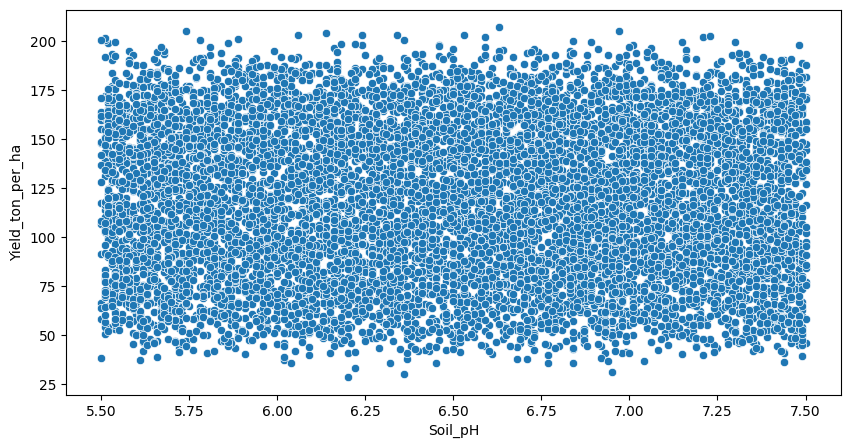

In [ ]:
plt.figure(figsize=(10,5))
sns.scatterplot(x=data['Soil_pH'],y=data['Yield_ton_per_ha'])

In [ ]:
num_data=data.select_dtypes('number')
Q1=num_data.quantile(.25)
Q3=num_data.quantile(.75)
IQR=Q3-Q1

lower_Range=Q1-1.5*IQR
upper_Range=Q3+1.5*IQR

outlayers=(num_data<lower_Range)|(num_data>upper_Range)
outlayers.sum()
data[outlayers.any(axis=1)]



,Crop,Region,Soil_Type,Soil_pH,Rainfall_mm,Temperature_C,Humidity_pct,Fertilizer_Used_kg,Irrigation,Pesticides_Used_kg,Planting_Density,Previous_Crop,Yield_ton_per_ha


In [ ]:
num_data.skew()

,0
Soil_pH,-0.035668
Rainfall_mm,0.020448
Temperature_C,0.009511
Humidity_pct,-0.014500
Fertilizer_Used_kg,-0.007440
Pesticides_Used_kg,-0.008255
Planting_Density,-0.003923
Yield_ton_per_ha,-0.008047


In [ ]:
mapping_dicts = [
    { 'Maize':0,'Wheat':1, 'Rice':2,'Barley':3 },
    {'Region_A':0,'Region_B':1,'Region_C':2,'Region_D':3},
    {'Sandy':0,'Loam':1,'Clay':2},
    {'Drip':0,'Sprinkler':1,'Flood':2},
    { 'Maize':0,'Wheat':1, 'Rice':2,'Barley':3}
]

columns_to_map = ['Crop','Region','Soil_Type','Irrigation','Previous_Crop']
count3=0
for col in columns_to_map:
    data[col] = data[col].map(mapping_dicts[count3])
    count3+=1


data

,Crop,Region,Soil_Type,Soil_pH,Rainfall_mm,Temperature_C,Humidity_pct,Fertilizer_Used_kg,Irrigation,Pesticides_Used_kg,Planting_Density,Previous_Crop,Yield_ton_per_ha
0,0,2,0,7.01,1485.4,19.7,40.3,105.1,0,10.2,23.2,2,101.48
1,3,3,1,5.79,399.4,29.1,55.4,221.8,1,35.5,7.4,3,127.39
2,2,2,2,7.24,980.9,30.5,74.4,61.2,1,40.0,5.1,1,68.99
3,0,3,1,6.79,1054.3,26.4,62.0,257.8,0,42.7,23.7,2,169.06
4,0,3,0,5.96,744.6,20.4,70.9,195.8,0,25.5,15.6,0,118.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,3,0,2,5.84,890.4,28.5,68.6,82.5,2,4.0,24.1,1,79.83
9996,0,0,0,6.91,614.2,30.0,84.2,85.2,2,21.7,8.3,0,68.24
9997,1,0,2,6.98,842.0,22.6,75.1,249.2,1,8.8,18.1,2,159.29
9998,1,3,0,7.27,924.2,26.8,50.8,146.1,1,3.3,18.1,0,99.08


In [ ]:
data.columns

Index(['Crop', 'Region', 'Soil_Type', 'Soil_pH', 'Rainfall_mm',
       'Temperature_C', 'Humidity_pct', 'Fertilizer_Used_kg', 'Irrigation',
       'Pesticides_Used_kg', 'Planting_Density', 'Previous_Crop',
       'Yield_ton_per_ha'],
      dtype='object')

In [ ]:
x=data.drop(columns='Yield_ton_per_ha')
y=data['Yield_ton_per_ha']

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x[x.columns]=scaler.fit_transform(x[x.columns])
x

,Crop,Region,Soil_Type,Soil_pH,Rainfall_mm,Temperature_C,Humidity_pct,Fertilizer_Used_kg,Irrigation,Pesticides_Used_kg,Planting_Density,Previous_Crop
0,-1.349494,0.457028,-1.224404,0.858326,1.717468,-0.911129,-1.140696,-0.972523,-1.520121,-1.035027,1.406199,0.388850
1,1.338563,1.347748,0.005411,-1.264404,-1.188980,0.712264,-0.268681,0.649199,-0.313293,0.727699,-1.302623,1.376029
2,0.442544,0.457028,1.235227,1.258512,0.367281,0.954046,0.828555,-1.582579,-0.313293,1.041228,-1.696945,-0.598329
3,-1.349494,1.347748,0.005411,0.475538,0.563720,0.245970,0.112464,1.149473,-1.520121,1.229345,1.491921,0.388850
4,-1.349494,1.347748,-1.224404,-0.968613,-0.265125,-0.790238,0.626432,0.287890,-1.520121,0.030970,0.103222,-1.585509
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1.338563,-1.324411,1.235227,-1.177407,0.125077,0.608643,0.493609,-1.286584,0.893536,-1.467000,1.560499,-0.598329
9996,-1.349494,-1.324411,-1.224404,0.684331,-0.614113,0.867695,1.394498,-1.249063,0.893536,-0.233788,-1.148323,-1.585509
9997,-0.453475,-1.324411,1.235227,0.806127,-0.004455,-0.410295,0.868979,1.029963,-0.313293,-1.132569,0.531833,0.388850
9998,-0.453475,1.347748,-1.224404,1.310710,0.215536,0.315051,-0.534328,-0.402766,-0.313293,-1.515771,0.531833,-1.585509


In [ ]:

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape
x_test.shape

(2000, 12)

In [ ]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_pre=model.predict(x_test)
display(y_pre[:20])
display(y_test.head(20))

array([163.52214024, 100.39673483,  56.33163745, 172.54104729,
        91.77533046,  60.72405331, 159.6220967 ,  55.7612693 ,
       105.70631363, 115.04031634,  77.71911422,  91.50059827,
       155.60366248, 195.89499682, 148.17107615, 152.74706228,
       156.64481078,  63.50537452, 114.89869266,  72.81343814])

,Yield_ton_per_ha
6252,162.31
4684,105.85
1731,56.56
4742,172.38
4521,96.73
6340,56.68
576,164.63
5202,55.61
6363,104.45
439,111.58


In [ ]:
from sklearn.metrics import r2_score
r2_scores=r2_score(y_test,y_pre)
r2_scores

0.9821452389366855

In [ ]:
from sklearn.model_selection import cross_val_score
cvs=cross_val_score(model,x,y,cv=5,scoring='r2')
cvs.mean()

np.float64(0.9824723736437688)

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
parameter={
    'n_neighbors':[5,7,9,11,13],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}
gsc= GridSearchCV(
    estimator=KNeighborsRegressor(),
    param_grid=parameter,
    cv=5,
    scoring='r2'
)
gsc.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=KNeighborsRegressor(),
             param_grid={'n_neighbors': [5, 7, 9, 11, 13], 'p': [1, 2],
                         'weights': ['uniform', 'distance']},
             scoring='r2')

In [ ]:
grid_result=pd.DataFrame(gsc.cv_results_)
grid_result


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,param_p,param_weights,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.010037,0.001658,0.231645,0.011389,5,1,uniform,"{'n_neighbors': 5, 'p': 1, 'weights': 'uniform'}",0.831164,0.828906,0.832866,0.833286,0.834956,0.832236,0.002056,20
1,0.009492,0.000581,0.220711,0.005818,5,1,distance,"{'n_neighbors': 5, 'p': 1, 'weights': 'distance'}",0.833979,0.830866,0.834598,0.836423,0.838266,0.834826,0.002483,19
2,0.009049,0.000228,0.166363,0.004492,5,2,uniform,"{'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}",0.855360,0.858301,0.858970,0.859819,0.865343,0.859559,0.003258,10
3,0.009132,0.000148,0.169153,0.004695,5,2,distance,"{'n_neighbors': 5, 'p': 2, 'weights': 'distance'}",0.857698,0.859921,0.861353,0.862039,0.867418,0.861686,0.003228,9
4,0.009067,0.000303,0.226193,0.004022,7,1,uniform,"{'n_neighbors': 7, 'p': 1, 'weights': 'uniform'}",0.840799,0.840347,0.847530,0.844140,0.849553,0.844474,0.003627,18
5,0.009621,0.000868,0.226640,0.005591,7,1,distance,"{'n_neighbors': 7, 'p': 1, 'weights': 'distance'}",0.844297,0.843101,0.849825,0.847623,0.852979,0.847565,0.003606,17
6,0.008957,0.000215,0.177212,0.006138,7,2,uniform,"{'n_neighbors': 7, 'p': 2, 'weights': 'uniform'}",0.866523,0.870474,0.869171,0.874324,0.877962,0.871691,0.004020,8
7,0.009042,0.000183,0.178226,0.005786,7,2,distance,"{'n_neighbors': 7, 'p': 2, 'weights': 'distance'}",0.868939,0.872172,0.871532,0.876504,0.879931,0.873816,0.003907,7
8,0.009147,0.000551,0.227875,0.005100,9,1,uniform,"{'n_neighbors': 9, 'p': 1, 'weights': 'uniform'}",0.847992,0.845617,0.854231,0.847539,0.854281,0.849932,0.003620,16
9,0.013131,0.001921,0.352372,0.047118,9,1,distance,"{'n_neighbors': 9, 'p': 1, 'weights': 'distance'}",0.851556,0.848602,0.856677,0.851115,0.857680,0.853126,0.003473,14


In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(
    random_state=42

)
grid_parameter={
    'n_estimators':[50,100],
    'max_depth':[None,10],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2]
}
grid=GridSearchCV(
    estimator=rf,
    param_grid=grid_parameter,
    cv=5,
    scoring='r2'
)
grid.fit(x_train,y_train)


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [None, 10], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100]},
             scoring='r2')

In [ ]:
grid_result=pd.DataFrame(grid.cv_results_)
grid_result[grid_result['mean_test_score']==grid_result['mean_test_score'].max()]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_min_samples_split,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
13,3.072504,0.178278,0.028868,0.000915,10,2,2,100,"{'max_depth': 10, 'min_samples_leaf': 2, 'min_...",0.980383,0.980882,0.980935,0.980212,0.980246,0.980532,0.000313,1
